# Week 2 Session 4: Class Activities

Ensemble learning plus a deeper look at classification evaluation metrics, then a full review of every classification model we have met so far.

## Activities in this Session

| # | Activity | Models | Dataset | Style |
|---|----------|--------|---------|-------|
| 1 | Ensembles + Evaluation Metrics (worked example) | Random Forest, XGBoost, LightGBM | `winequality-red.csv` (multiclass) | Answers shown |
| 2 | Ensembles on a harder dataset | Random Forest, XGBoost, LightGBM | `ai_job_dataset.csv` (multiclass) | TODO |
| 3 | Full Review: all 6 classification models | Logistic Regression, SVM, Decision Tree, Random Forest, XGBoost, LightGBM | `FuelConsumptionCo2.csv` (5 classes) | TODO |

Each activity block below has a short **Activity Card** explaining the task, dataset, and target. Complete the **TODO** sections in Activities 2 and 3.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# XGBoost and LightGBM are separate libraries (already installed in the mlcourse env)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)


---
# Activity 1 -- Ensembles + Evaluation Metrics (Wine Quality, Multiclass)

> ### Activity Card
> **Goal:** Train Random Forest, XGBoost, and LightGBM on the multiclass wine problem and read the full set of evaluation metrics.
> **Dataset:** `winequality-red.csv` (1599 red wines, 11 chemical features)
> **Features (X):** 11 chemical measurements
> **Target (y):** multiclass -- `low` (quality <= 4), `medium` (5-6), `high` (>= 7)
> **Task:** Fit all three ensemble models, compute the confusion matrix + classification report for each, explain what each metric means.

This activity is the teaching example for the whole session -- **the answers are worked out below**. Activities 2 and 3 will ask you to do it yourself.


#### What is Ensemble Learning?
An **ensemble** combines the predictions of many models to produce a single, stronger prediction.

Two main families of ensembles:

| Family | Idea | Example |
|--------|------|---------|
| **Bagging** | Train many models **in parallel** on random subsets of the data, then average their votes. Reduces variance. | Random Forest |
| **Boosting** | Train models **sequentially**, where each new model focuses on the mistakes of the previous one. Reduces bias. | XGBoost, LightGBM |

#### What is Random Forest?
Random Forest = many Decision Trees, each trained on a different random sample of the data AND a different random subset of features. The forest votes on the final prediction. It is more robust than a single Decision Tree and rarely overfits.

#### What is XGBoost?
XGBoost (Extreme Gradient Boosting) trains trees **one after another**, with each new tree correcting the residual errors of the trees before it. It is one of the most popular algorithms on Kaggle.

#### What is LightGBM?
LightGBM is another gradient boosting library from Microsoft. It grows trees **leaf-wise** (not level-wise like XGBoost), which often makes it 5-10x faster on large datasets while still being accurate.


In [2]:
# Load the red wine quality dataset (note: uses ';' as the separator)
wine = pd.read_csv('../../Datasets/winequality-red.csv', sep=';')

# Display basic information about the dataset
print('Shape:', wine.shape)
print('\nQuality distribution:')
print(wine['quality'].value_counts().sort_index())

display(wine.head())


Shape: (1599, 12)

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Build the feature matrix and a MULTICLASS target (low / medium / high)
feature_cols = [c for c in wine.columns if c != 'quality']
X_wine = wine[feature_cols]

# Bin the quality score into three categories
def bin_quality(q):
    if q <= 4:
        return 'low'
    if q <= 6:
        return 'medium'
    return 'high'

y_multi = wine['quality'].apply(bin_quality)

print('Multiclass counts:')
print(y_multi.value_counts())

# Train-test split (stratify keeps the low/medium/high ratio in both splits)
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_multi, test_size=0.2,
                                                     random_state=42, stratify=y_multi)

# XGBoost and LightGBM need numeric class labels for multiclass, so we'll encode them
le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f'\nEncoded classes (alphabetical order): {list(le.classes_)}')
print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')


Multiclass counts:
quality
medium    1319
high       217
low         63
Name: count, dtype: int64

Encoded classes (alphabetical order): ['high', 'low', 'medium']
Train size: (1279, 11)  |  Test size: (320, 11)


### 1.1 Random Forest

Random Forests do **not** need feature scaling (they split on raw values), so we skip StandardScaler here.


In [4]:
# Train a Random Forest with 200 trees
model_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Predict on the test set (string labels)
y_pred_rf = model_rf.predict(X_test)

# Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8594

Classification Report:
              precision    recall  f1-score   support

        high       0.67      0.51      0.58        43
         low       0.00      0.00      0.00        13
      medium       0.88      0.96      0.92       264

    accuracy                           0.86       320
   macro avg       0.52      0.49      0.50       320
weighted avg       0.82      0.86      0.84       320



/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

### 1.2 Multiclass Confusion Matrix -- How to Read It

For a **multiclass** problem the confusion matrix is an N x N grid (here 3 x 3).

- **Rows** = actual class
- **Columns** = predicted class
- **Diagonal** cells = correct predictions
- **Off-diagonal** cells = confusions (which class the model mistakes for which)

#### What about TP / FP / TN / FN in multiclass?
The TP / FP / TN / FN vocabulary is defined for **binary** problems. In multiclass we use the **one-vs-rest** trick: pick one class at a time and treat all the other classes as "negative". scikit-learn does this automatically inside the `classification_report`, giving you **per-class** precision, recall and F1.


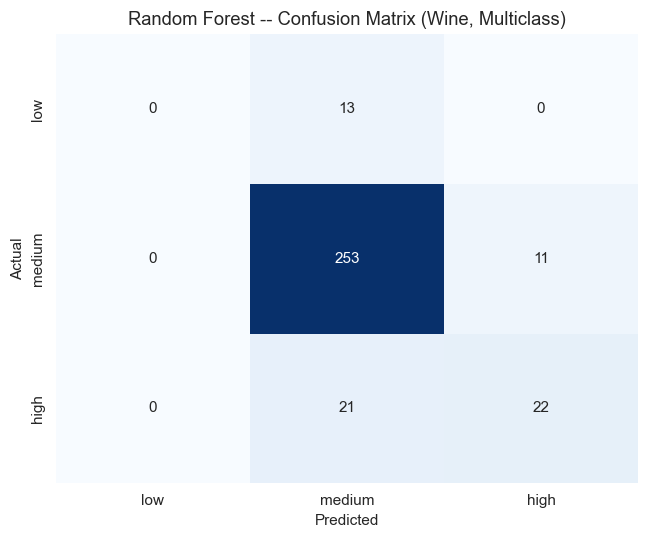

In [5]:
# Plot the confusion matrix as a heatmap (labels in a fixed order for readability)
labels = ['low', 'medium', 'high']
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest -- Confusion Matrix (Wine, Multiclass)')
plt.tight_layout()
plt.show()


### 1.3 Precision, Recall and F1 -- What Do They Mean?

#### What is Precision?
**Precision** = TP / (TP + FP) -- of everything the model **predicted as class X**, how many were really class X? High precision = few false alarms.

#### What is Recall?
**Recall** = TP / (TP + FN) -- of all the things that were **actually class X**, how many did the model catch? High recall = few missed detections.

#### What is F1?
**F1** = 2 * (Precision * Recall) / (Precision + Recall) -- harmonic mean of precision and recall. A model only gets a high F1 if it scores well on **both**.

In the `classification_report` above:
- The top rows show Precision / Recall / F1 **per class**.
- **`macro avg`** = unweighted average across classes (every class counts equally).
- **`weighted avg`** = average weighted by `support` (larger classes count more). Usually close to accuracy.

Choose your metric based on the cost of each kind of mistake:
- Spam filter -- prefer high **Precision** (don't hide real email in the spam folder).
- Cancer screening -- prefer high **Recall** (don't miss a diagnosis).
- Balanced concerns -- use **F1**.


In [6]:
# Compute macro and weighted averages explicitly so you can see them
print(f"Accuracy:      {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Macro F1:      {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Weighted F1:   {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Macro Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Macro Recall:    {recall_score(y_test, y_pred_rf, average='macro'):.4f}")


Accuracy:      0.8594
Macro F1:      0.4991
Weighted F1:   0.8354
Macro Precision: 0.5161
Macro Recall:    0.4900


/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 1.4 XGBoost

XGBoost Accuracy: 0.8562

Classification Report:
              precision    recall  f1-score   support

        high       0.64      0.53      0.58        43
         low       0.00      0.00      0.00        13
      medium       0.89      0.95      0.92       264

    accuracy                           0.86       320
   macro avg       0.51      0.50      0.50       320
weighted avg       0.82      0.86      0.84       320



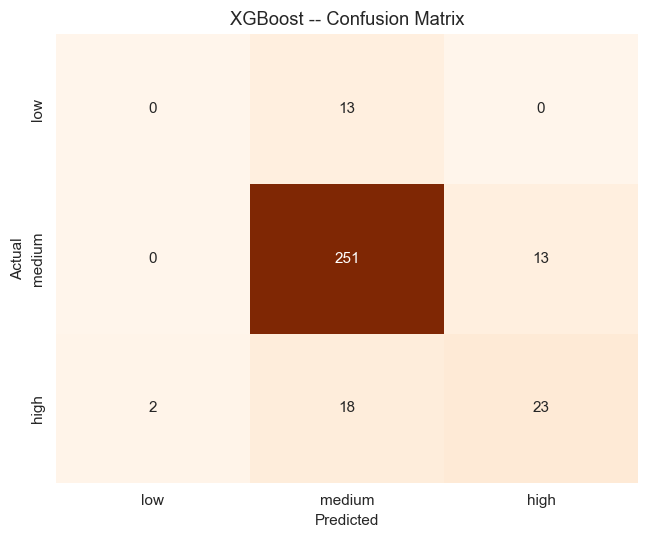

In [7]:
# Train an XGBoost classifier. Remember: XGBoost needs numeric labels (y_train_enc).
model_xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                          eval_metric='mlogloss', random_state=42, n_jobs=-1)
model_xgb.fit(X_train, y_train_enc)

# Predict (output is encoded integers) then decode back to 'low'/'medium'/'high'
y_pred_xgb_enc = model_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

# Evaluate
print(f'XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix heatmap
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('XGBoost -- Confusion Matrix')
plt.tight_layout()
plt.show()


### 1.5 LightGBM

LightGBM Accuracy: 0.8656

Classification Report:
              precision    recall  f1-score   support

        high       0.68      0.58      0.62        43
         low       0.00      0.00      0.00        13
      medium       0.89      0.95      0.92       264

    accuracy                           0.87       320
   macro avg       0.52      0.51      0.52       320
weighted avg       0.83      0.87      0.84       320



/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macuser/miniconda3/envs/mlcourse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

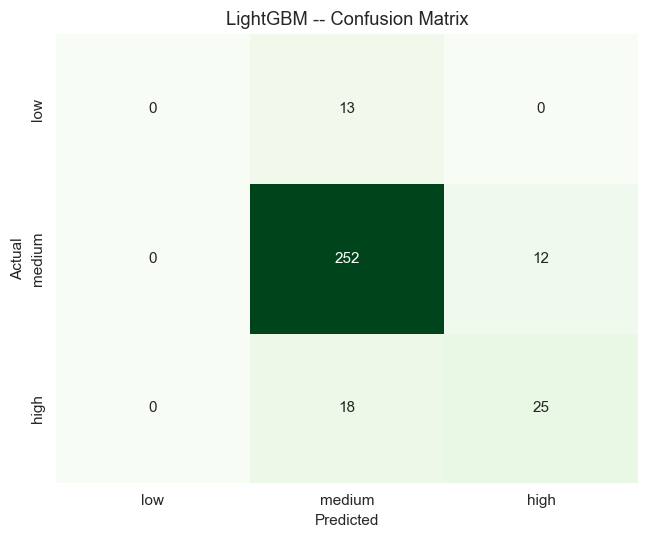

In [8]:
# Train a LightGBM classifier. Also needs numeric labels.
model_lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.1,
                            random_state=42, n_jobs=-1, verbose=-1)
model_lgbm.fit(X_train, y_train_enc)

# Predict and decode
y_pred_lgbm_enc = model_lgbm.predict(X_test)
y_pred_lgbm = le.inverse_transform(y_pred_lgbm_enc)

# Evaluate
print(f'LightGBM Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lgbm))

# Confusion matrix heatmap
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('LightGBM -- Confusion Matrix')
plt.tight_layout()
plt.show()


### 1.6 Compare the Three Ensemble Models

,Model,Accuracy,Macro F1,Weighted F1
2,LightGBM,0.8656,0.5155,0.8441
1,XGBoost,0.8562,0.5006,0.8368
0,Random Forest,0.8594,0.4991,0.8354


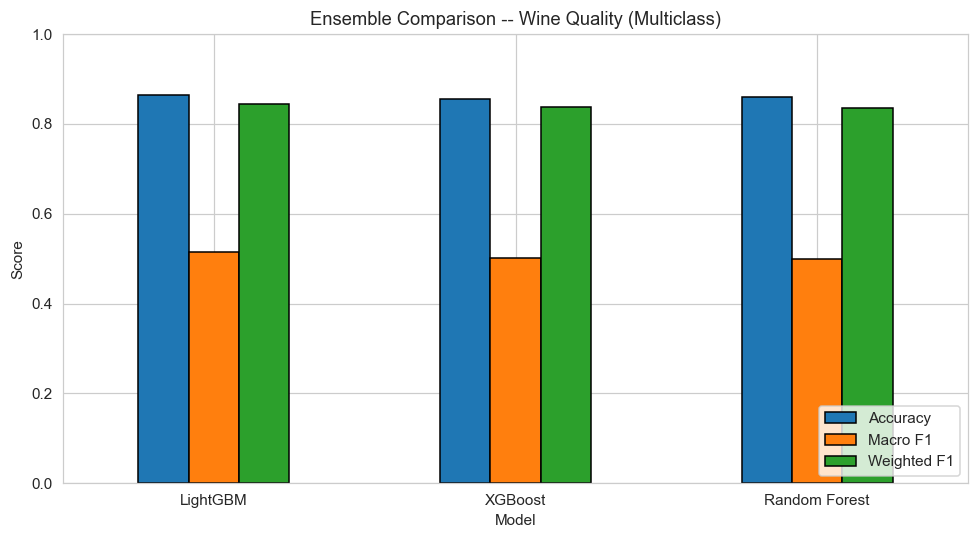

In [9]:
# Build one summary table comparing all three ensemble models
rows = []
for name, y_pred in [('Random Forest', y_pred_rf),
                     ('XGBoost',       y_pred_xgb),
                     ('LightGBM',      y_pred_lgbm)]:
    rows.append({
        'Model':       name,
        'Accuracy':    accuracy_score(y_test, y_pred),
        'Macro F1':    f1_score(y_test, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted'),
    })

summary = pd.DataFrame(rows).sort_values('Macro F1', ascending=False)
display(summary.round(4))

# Grouped bar chart
ax = summary.set_index('Model')[['Accuracy', 'Macro F1', 'Weighted F1']].plot(
    kind='bar', figsize=(9, 5), edgecolor='black', rot=0)
ax.set_ylim(0, 1)
ax.set_title('Ensemble Comparison -- Wine Quality (Multiclass)')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 1.7 Feature Importance (Random Forest)

One of the biggest advantages of tree-based models is that they expose **feature importance** out of the box -- which chemical properties matter most for predicting wine quality?


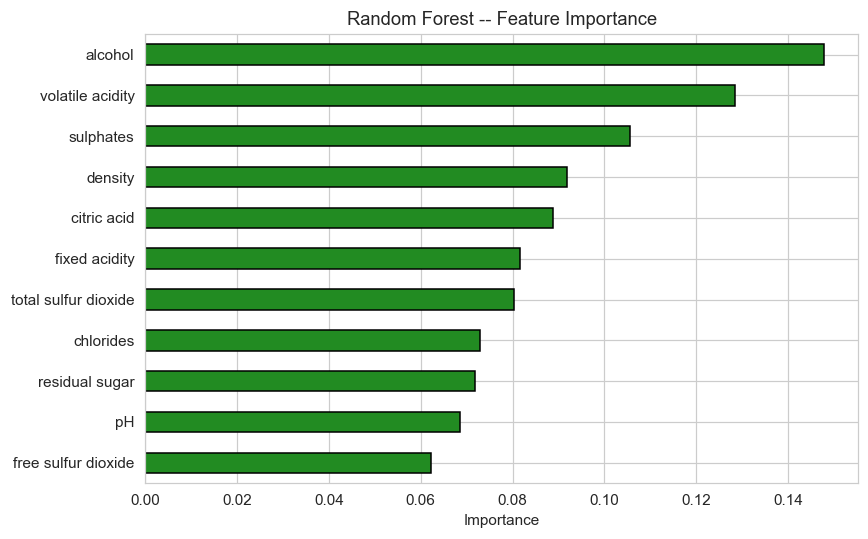

In [10]:
importances = pd.Series(model_rf.feature_importances_, index=X_wine.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.title('Random Forest -- Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### Discussion Questions (Activity 1)

1. Which class (`low`, `medium`, `high`) has the **lowest recall** across all three models? Why is this class so hard? (check the `support` numbers).
2. Which chemical property is the most important predictor according to the Random Forest?
3. The three ensembles usually score within 1-2 percentage points of each other on this dataset. Why might that be? What kind of dataset would make the differences bigger?


---
# Activity 2 -- Ensembles on AI Job Postings (Multiclass)

Same three ensemble models as in Activity 1, but on a larger, harder multiclass dataset. **No answers are provided this time -- you apply the pattern from Activity 1 yourself.**

**Shared context for Activities 2a-2c:**
- **Dataset:** `ai_job_dataset.csv` (15,000 AI/ML job postings)
- **Features (X):** `salary_usd`, `years_experience`, `remote_ratio`, `job_description_length`, `benefits_score` (numeric only)
- **Target (y):** `experience_level` -- 4 classes: **EN** (entry), **MI** (mid), **SE** (senior), **EX** (executive)


In [11]:
# Load the AI job dataset
jobs = pd.read_csv('../../Datasets/ai_job_dataset.csv')

# Display basic information
print('Shape:', jobs.shape)
print('\nExperience level distribution:')
print(jobs['experience_level'].value_counts())

display(jobs.head(3))


Shape: (15000, 19)

Experience level distribution:
experience_level
MI    3781
EX    3760
SE    3741
EN    3718
Name: count, dtype: int64


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech


In [12]:
# Select numeric features and target
num_features = ['salary_usd', 'years_experience', 'remote_ratio',
                'job_description_length', 'benefits_score']

jobs_subset = jobs[num_features + ['experience_level']].dropna()

X_jobs = jobs_subset[num_features]
y_jobs_raw = jobs_subset['experience_level']

# Encode the 4 experience levels into integers
le_jobs = LabelEncoder().fit(y_jobs_raw)
y_jobs = le_jobs.transform(y_jobs_raw)

print(f'Feature matrix shape: {X_jobs.shape}')
print(f'Classes: {dict(zip(le_jobs.classes_, range(len(le_jobs.classes_))))}')

# Train-test split (stratify preserves class balance)
X_train_j, X_test_j, y_train_j, y_test_j = train_test_split(X_jobs, y_jobs, test_size=0.2,
                                                             random_state=42, stratify=y_jobs)
print(f'\nTrain size: {X_train_j.shape}  |  Test size: {X_test_j.shape}')


Feature matrix shape: (15000, 5)
Classes: {'EN': 0, 'EX': 1, 'MI': 2, 'SE': 3}

Train size: (12000, 5)  |  Test size: (3000, 5)


## Activity 2a -- Random Forest

> ### Activity Card
> **Goal:** Train a Random Forest to predict `experience_level`.
> **Task:** Fit `RandomForestClassifier(n_estimators=200)`, report accuracy + classification report + confusion matrix.


In [13]:
# TODO: Train a Random Forest on the AI jobs dataset
model_rf_jobs = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)


# TODO: Predict on the test set


# TODO: Evaluate using accuracy_score and classification_report
# Hint: use target_names=le_jobs.classes_ in classification_report so you see EN/MI/SE/EX


# TODO: Plot the confusion matrix as a heatmap


## Activity 2b -- XGBoost

> ### Activity Card
> **Goal:** Train an XGBoost classifier on the 4-class experience-level problem.
> **Task:** Fit `XGBClassifier`, report accuracy + classification report + confusion matrix.


In [14]:
# TODO: Train an XGBoost classifier
# Hint: n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric='mlogloss'
model_xgb_jobs = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               eval_metric='mlogloss', random_state=42, n_jobs=-1)


# TODO: Predict and evaluate


# TODO: Plot the confusion matrix


## Activity 2c -- LightGBM

> ### Activity Card
> **Goal:** Train a LightGBM classifier on the same 4-class problem.
> **Task:** Fit `LGBMClassifier`, report accuracy + classification report + confusion matrix.


In [15]:
# TODO: Train a LightGBM classifier
model_lgbm_jobs = LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                 random_state=42, n_jobs=-1, verbose=-1)


# TODO: Predict and evaluate


# TODO: Plot the confusion matrix


### 2.1 Compare the Three Ensemble Models -- AI Jobs

In [16]:
# TODO: Build a summary DataFrame of all three ensemble models on the AI jobs data
# Columns: 'Model', 'Accuracy', 'Macro F1', 'Weighted F1'
# Hint: copy the pattern from Activity 1.6 above


# TODO: Plot the comparison as a grouped bar chart


### More Activities (Activity 2)

1. Which ensemble model wins on **Macro F1**? Is it the same winner as on **Accuracy**?
2. Look at the confusion matrix for the winning model -- which two experience levels are most often confused? Does that make intuitive sense (e.g. MI vs SE might overlap more than EN vs EX)?
3. **Bonus:** drop `salary_usd` from the features and re-train any one model. How much does Macro F1 drop? That tells you how much of the signal was coming from salary alone.


In [17]:
# TODO: Bonus -- try dropping salary_usd and see the impact on Macro F1




---
# Activity 3 -- Full Review (All 6 Classification Models)

Time to revisit **every classification model from Week 2** in one go. **No answers are provided.**

**Shared context for Activities 3a-3f:**
- **Dataset:** `FuelConsumptionCo2.csv` (same dataset you used for regression in Week 1, now as a classification problem)
- **Features (X):** `ENGINESIZE`, `CYLINDERS`, `FUELCONSUMPTION_CITY`, `FUELCONSUMPTION_HWY`, `FUELCONSUMPTION_COMB`, `CO2EMISSIONS`
- **Target (y):** `VEHICLECLASS` -- filtered to the **top 5** classes: `MID-SIZE`, `COMPACT`, `SUV - SMALL`, `SUV - STANDARD`, `FULL-SIZE`
- **Goal:** train all **6** classification models (3 from Session 3, 3 from Session 4), put them in a single comparison table, pick a winner.

### Models to train
| # | Model | From |
|---|-------|------|
| 3a | Logistic Regression | Session 3 |
| 3b | SVM (RBF kernel) | Session 3 |
| 3c | Decision Tree | Session 3 |
| 3d | Random Forest | Session 4 |
| 3e | XGBoost | Session 4 |
| 3f | LightGBM | Session 4 |


In [18]:
# Load the FuelConsumption dataset and keep only the top 5 vehicle classes
fuel = pd.read_csv('../../Datasets/FuelConsumptionCo2.csv')

top5_classes = ['MID-SIZE', 'COMPACT', 'SUV - SMALL', 'SUV - STANDARD', 'FULL-SIZE']
fuel_top5 = fuel[fuel['VEHICLECLASS'].isin(top5_classes)].copy()

print(f'Filtered shape: {fuel_top5.shape}')
print('\nClass counts:')
print(fuel_top5['VEHICLECLASS'].value_counts())
display(fuel_top5.head())


Filtered shape: (700, 13)

Class counts:
VEHICLECLASS
MID-SIZE          178
COMPACT           172
SUV - SMALL       154
SUV - STANDARD    110
FULL-SIZE          86
Name: count, dtype: int64


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [19]:
# Build features and target
feature_cols_f = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
                  'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']

X_fuel = fuel_top5[feature_cols_f]
y_fuel_raw = fuel_top5['VEHICLECLASS']

# Encode class labels for XGBoost / LightGBM
le_fuel = LabelEncoder().fit(y_fuel_raw)
y_fuel_enc = le_fuel.transform(y_fuel_raw)

print(f'Feature matrix shape: {X_fuel.shape}')
print(f'Classes (encoded): {dict(zip(le_fuel.classes_, range(len(le_fuel.classes_))))}')

# Train-test split (stratify preserves class balance)
X_train_f, X_test_f, y_train_f_enc, y_test_f_enc = train_test_split(
    X_fuel, y_fuel_enc, test_size=0.2, random_state=42, stratify=y_fuel_enc
)

# String labels too (for models that work with either)
y_train_f = le_fuel.inverse_transform(y_train_f_enc)
y_test_f  = le_fuel.inverse_transform(y_test_f_enc)

# Scale features (needed for Logistic Regression and SVM)
scaler_f = StandardScaler()
X_train_f_s = scaler_f.fit_transform(X_train_f)
X_test_f_s  = scaler_f.transform(X_test_f)

print(f'\nTrain size: {X_train_f.shape}  |  Test size: {X_test_f.shape}')


Feature matrix shape: (700, 6)
Classes (encoded): {'COMPACT': 0, 'FULL-SIZE': 1, 'MID-SIZE': 2, 'SUV - SMALL': 3, 'SUV - STANDARD': 4}

Train size: (560, 6)  |  Test size: (140, 6)


## Activity 3a -- Logistic Regression (Session 3 review)

> ### Activity Card
> **Goal:** Train a multinomial Logistic Regression to predict `VEHICLECLASS`.
> **Features:** scaled 6 numeric features
> **Task:** Fit `LogisticRegression(max_iter=1000)`, evaluate with accuracy + classification report.


In [20]:
# TODO: Train a Logistic Regression model on the scaled features (X_train_f_s, y_train_f)


# TODO: Predict on X_test_f_s


# TODO: Evaluate using accuracy_score and classification_report


## Activity 3b -- Support Vector Machine (Session 3 review)

> ### Activity Card
> **Goal:** Train an RBF-kernel SVM on the same problem.
> **Features:** scaled 6 numeric features
> **Task:** Fit `SVC(kernel='rbf', C=1.0)`, evaluate.


In [21]:
# TODO: Train an SVM on the scaled features


# TODO: Predict and evaluate


## Activity 3c -- Decision Tree (Session 3 review)

> ### Activity Card
> **Goal:** Train a Decision Tree (no scaling needed).
> **Features:** raw 6 numeric features
> **Task:** Fit `DecisionTreeClassifier(max_depth=6)`, evaluate.


In [22]:
# TODO: Train a Decision Tree on the UNSCALED features (X_train_f, y_train_f)


# TODO: Predict and evaluate


## Activity 3d -- Random Forest (Session 4)

> ### Activity Card
> **Goal:** Train a Random Forest on the same problem.
> **Task:** Fit `RandomForestClassifier(n_estimators=200)`, evaluate, plot feature importance.


In [23]:
# TODO: Train a Random Forest on the UNSCALED features


# TODO: Predict, evaluate, and plot feature importance


## Activity 3e -- XGBoost (Session 4)

> ### Activity Card
> **Goal:** Train an XGBoost classifier.
> **Task:** Fit `XGBClassifier`, remember to use the ENCODED labels (y_train_f_enc, y_test_f_enc), evaluate.


In [24]:
# TODO: Train an XGBoost classifier on the UNSCALED features with ENCODED labels
# Hint: n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric='mlogloss'


# TODO: Predict (output will be encoded integers) and decode with le_fuel.inverse_transform


# TODO: Evaluate


## Activity 3f -- LightGBM (Session 4)

> ### Activity Card
> **Goal:** Train a LightGBM classifier.
> **Task:** Fit `LGBMClassifier`, evaluate.


In [25]:
# TODO: Train a LightGBM classifier on the UNSCALED features with ENCODED labels


# TODO: Predict, decode, and evaluate


### 3.1 Final Bake-Off -- All 6 Models

Put every model into one comparison table so you can see, in a single glance, who wins.


In [26]:
# TODO: Build a summary DataFrame with one row per model.
# Columns: 'Model', 'Accuracy', 'Macro F1', 'Weighted F1'
# Rows: Logistic Regression, SVM, Decision Tree, Random Forest, XGBoost, LightGBM
# Hint:
# rows = []
# for name, y_pred in [('Logistic Regression', y_pred_lr),
#                      ('SVM',                 y_pred_svm),
#                      ('Decision Tree',       y_pred_dt),
#                      ('Random Forest',       y_pred_rf_f),
#                      ('XGBoost',             y_pred_xgb_f),
#                      ('LightGBM',            y_pred_lgbm_f)]:
#     rows.append({
#         'Model':       name,
#         'Accuracy':    accuracy_score(y_test_f, y_pred),
#         'Macro F1':    f1_score(y_test_f, y_pred, average='macro'),
#         'Weighted F1': f1_score(y_test_f, y_pred, average='weighted'),
#     })
# summary_all = pd.DataFrame(rows).sort_values('Macro F1', ascending=False)
# display(summary_all.round(4))


# TODO: Plot the comparison as a grouped bar chart


### More Activities (Activity 3)

1. Which model wins overall on this dataset? Is it a Session 3 model or a Session 4 model?
2. Look at the **Logistic Regression** confusion matrix -- which two vehicle classes get confused the most? Does that surprise you?
3. Which class is the easiest to predict across **all** models? What makes it easy?
4. Which of the 6 models is the **fastest to train** on this dataset? Which is the **slowest**? (add timing with `%%time` at the top of a training cell).
5. **Stretch:** add a 7th class to the target (the 6th most common `VEHICLECLASS`) and re-run any one model. Does the accuracy drop?


In [27]:
# TODO:


